In [54]:
# defining root location of the project on local system (change this to your own path after pulling)
import numpy as np 
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

# set up plotting config
mpl.rcParams['mathtext.fontset'] = 'stix'  # or 'dejavusans', 'cm', 'custom'
mpl.rcParams['font.family'] = 'STIXGeneral'  # Matches STIX math font
# set tick font size
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
# set default fontsize
mpl.rcParams['font.size'] = 16

# define root
ROOT = "/home/andreasstillits/coding/Leaves1D/"
%pwd

'/home/andreasstillits/coding/Leaves1D/figures/scripts'

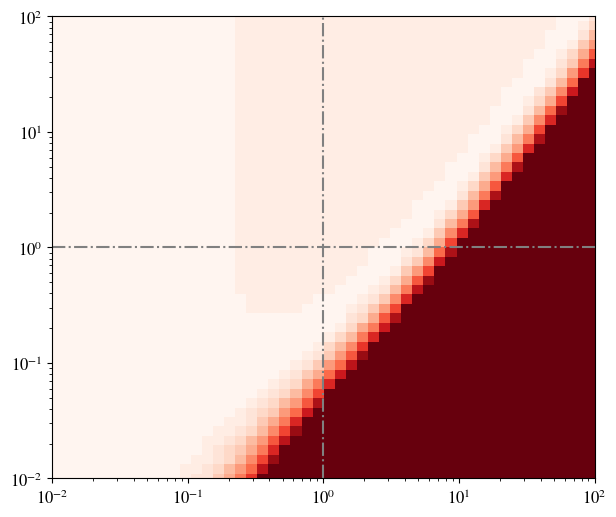

In [81]:
def transform_heatmap(map: np.ndarray, vmin: float = 5) -> np.ndarray:
    mask = map < vmin
    transformed_map = map.copy()
    transformed_map[mask] = 0
    transformed_map[~mask] = 1
    return transformed_map

def colormap(name: str):
    colors = [[1, 1, 1, 0], to_rgb(name) + (1,)]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([0, 1], cmap.N)
    return cmap, norm

def plot(ax: plt.Axes, map: np.ndarray, cmap: ListedColormap, norm: BoundaryNorm, zorder: int) -> None:
    N = map.shape[0]
    vmin, vmax = 0.01, 100
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([1, 1], [vmin, vmax], color="grey", linestyle="-.", zorder=2)
    ax.plot([vmin, vmax], [1, 1], color="grey", linestyle="-.", zorder=2)
    taus = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    gammas = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    ax.pcolormesh(taus, gammas, map, cmap=cmap, norm=norm, shading='auto', zorder=zorder)


vmin = 10

# load heatmap data
d30__ = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/gradients/3Dv0D_typical.txt", delimiter=";").T   # 3D vs 0D
d30 = 100 * np.loadtxt(ROOT + "supplementary/files/lateral_scanning/fine_grained/typical_3Dv0D_error.txt", delimiter=";").T   # 3D vs 0D
d30_ = transform_heatmap(d30, vmin=vmin)

d31 = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/lateral/3Dv1D_typical.txt", delimiter=";").T   # 3D vs 1D
d31_ = transform_heatmap(d31, vmin=vmin)

assert len(d30) == len(d31), "Heatmaps must have the same shape"
N = len(d30)
taus = np.exp(np.linspace(np.log(0.01), np.log(100), N))
gammas = np.exp(np.linspace(np.log(0.01), np.log(100), N))
d10 = np.zeros_like(d30)  # Placeholder for 3D vs 0D error, to be calculated based on taus and gammas
for i, tau in enumerate(taus):
    for j, gamma in enumerate(gammas):
        d10[j, i] = 100 * ((1/gamma + 1/(tau*np.tanh(tau)))/(1/gamma + 1/tau**2)-1)
#err = 100* (1/g)/() #(taus / np.tanh(taus) - 1)
#d10 = np.array([err for _ in range(N)])
d10_ = transform_heatmap(d10, vmin=vmin)

cmap_red, norm = colormap("#b21117ff")  # "#a71413ff"
cmap_green, _ = colormap("#3d9c5bff")   # "#16440fff"
cmap_blue, _ = colormap("#206eb3ff")   # "#130a5eff"

# plotting
fig, ax = plt.subplots(figsize=(7, 6))

cN = 21
cmap = plt.get_cmap("Reds", cN)
cmap = ListedColormap(cmap(np.arange(cmap.N)))
bounds = np.linspace(0, 10, cN)
norm = BoundaryNorm(bounds, cmap.N)

calc = d10 + d31 + d10*d31
diff = np.abs(d30__ - calc) / calc


plot(ax, diff, cmap, norm, zorder=1)

plt.show()